In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [187]:
df_all = pd.read_csv('/Users/gregorko/Desktop/Archive/data/symbol_info_3-25.csv')
print("Dataset shape:", df_all.shape)

summary_all = pd.DataFrame({"column": df_all.columns,
    "dtype": df_all.dtypes.astype(str).values,
    "missing_values": df_all.isna().sum().values,
})
df["m_cap_b"] = df["market_cap"] / 1000000000

display(df_all.head())
display(summary_all)

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


,column,dtype,missing_values
0,symbol,object,0
1,company_name,object,0
2,sector,object,2
3,industry,object,2
4,market_cap,int64,0
5,enterprise_value,uint64,0
6,current_price,float64,0
7,previous_close,float64,0
8,fifty_two_week_high,float64,0
9,fifty_two_week_low,float64,0


In [205]:
df = df_all.copy()
df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["sector"] == "Utilities")
][["company_name", "sector","symbol", "market_cap","industry","total_revenue","profit_margins","beta"]]

df["market_cap_billion"] = df["market_cap"] / 1000000000

summary = pd.DataFrame({"column": df.columns,
    "dtype": df.dtypes.astype(str).values,
})

display(df)

,company_name,sector,symbol,market_cap,industry,total_revenue,profit_margins,beta,market_cap_billion
73,"NextEra Energy, Inc.",Utilities,NEE,146357272576,Utilities - Regulated Electric,24753000448,0.28061,0.574,146.357273
117,Southern Company (The),Utilities,SO,98679357440,Utilities - Regulated Electric,26723999744,0.16468,0.446,98.679357
123,Duke Energy Corporation (Holdin,Utilities,DUK,93366894592,Utilities - Regulated Electric,29934000128,0.15113,0.465,93.366895
124,GE Vernova Inc.,Utilities,GEV,92931710976,Utilities - Renewable,34935001088,0.04443,0.000,92.931711
172,Constellation Energy Corporatio,Utilities,CEG,69705211904,Utilities - Renewable,23567998976,0.15907,0.884,69.705212
209,American Electric Power Company,Utilities,AEP,56683405312,Utilities - Regulated Electric,19721299968,0.15045,0.492,56.683405
249,"Dominion Energy, Inc.",Utilities,D,46845739008,Utilities - Regulated Electric,14458999808,0.14690,0.584,46.845739
255,DBA Sempra,Utilities,SRE,45602037760,Utilities - Diversified,13185000448,0.21699,0.776,45.602038
260,Exelon Corporation,Utilities,EXC,45015011328,Utilities - Regulated Electric,23028000768,0.10683,0.580,45.015011
261,Vistra Corp.,Utilities,VST,44866764800,Utilities - Independent Power Producers,17223999488,0.15438,1.232,44.866765


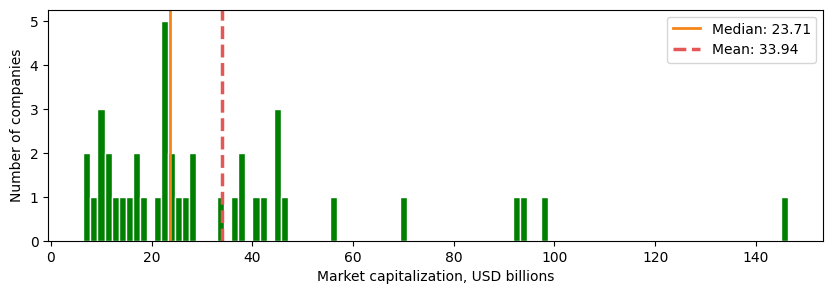

In [206]:
m_cap_b = df["market_cap_billion"].dropna()
figure, graph1 = plt.subplots(figsize=(10, 3))
graph1.hist(
m_cap_b, bins=100, color="green", edgecolor="white"
)

graph1.set_title("")
graph1.set_xlabel("Market capitalization, USD billions")
graph1.set_ylabel("Number of companies")

median_g1 = m_cap_b.median()
mean_g1 = m_cap_b.mean()

graph1.axvline(median_g1, color="#F58518", linestyle="-", linewidth=2, label=f"Median: {median_g1:.2f}")
graph1.axvline(mean_g1, color="#E45756", linestyle="--", linewidth=2.5, label=f"Mean: {mean_g1:.2f}")
graph1.legend()
plt.show()


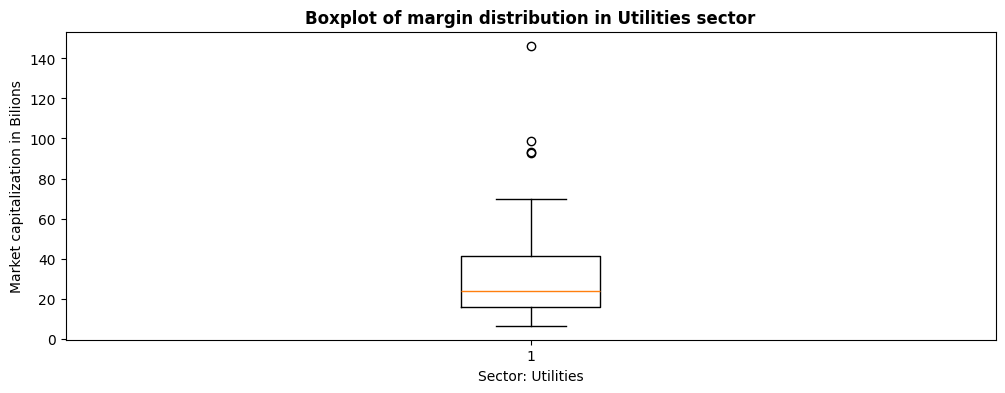

In [223]:
figure2, boxplot = plt.subplots(figsize=(12, 4))
boxplot.boxplot(m_cap_b)

boxplot.set_title("Boxplot of margin distribution in Utilities sector")
boxplot.set_ylabel("Market capitalization in Bilions")
boxplot.set_xlabel("Sector: Utilities")
plt.show()


plt.show()

df_new = df[df["market_cap_billion"] <= 80].copy()

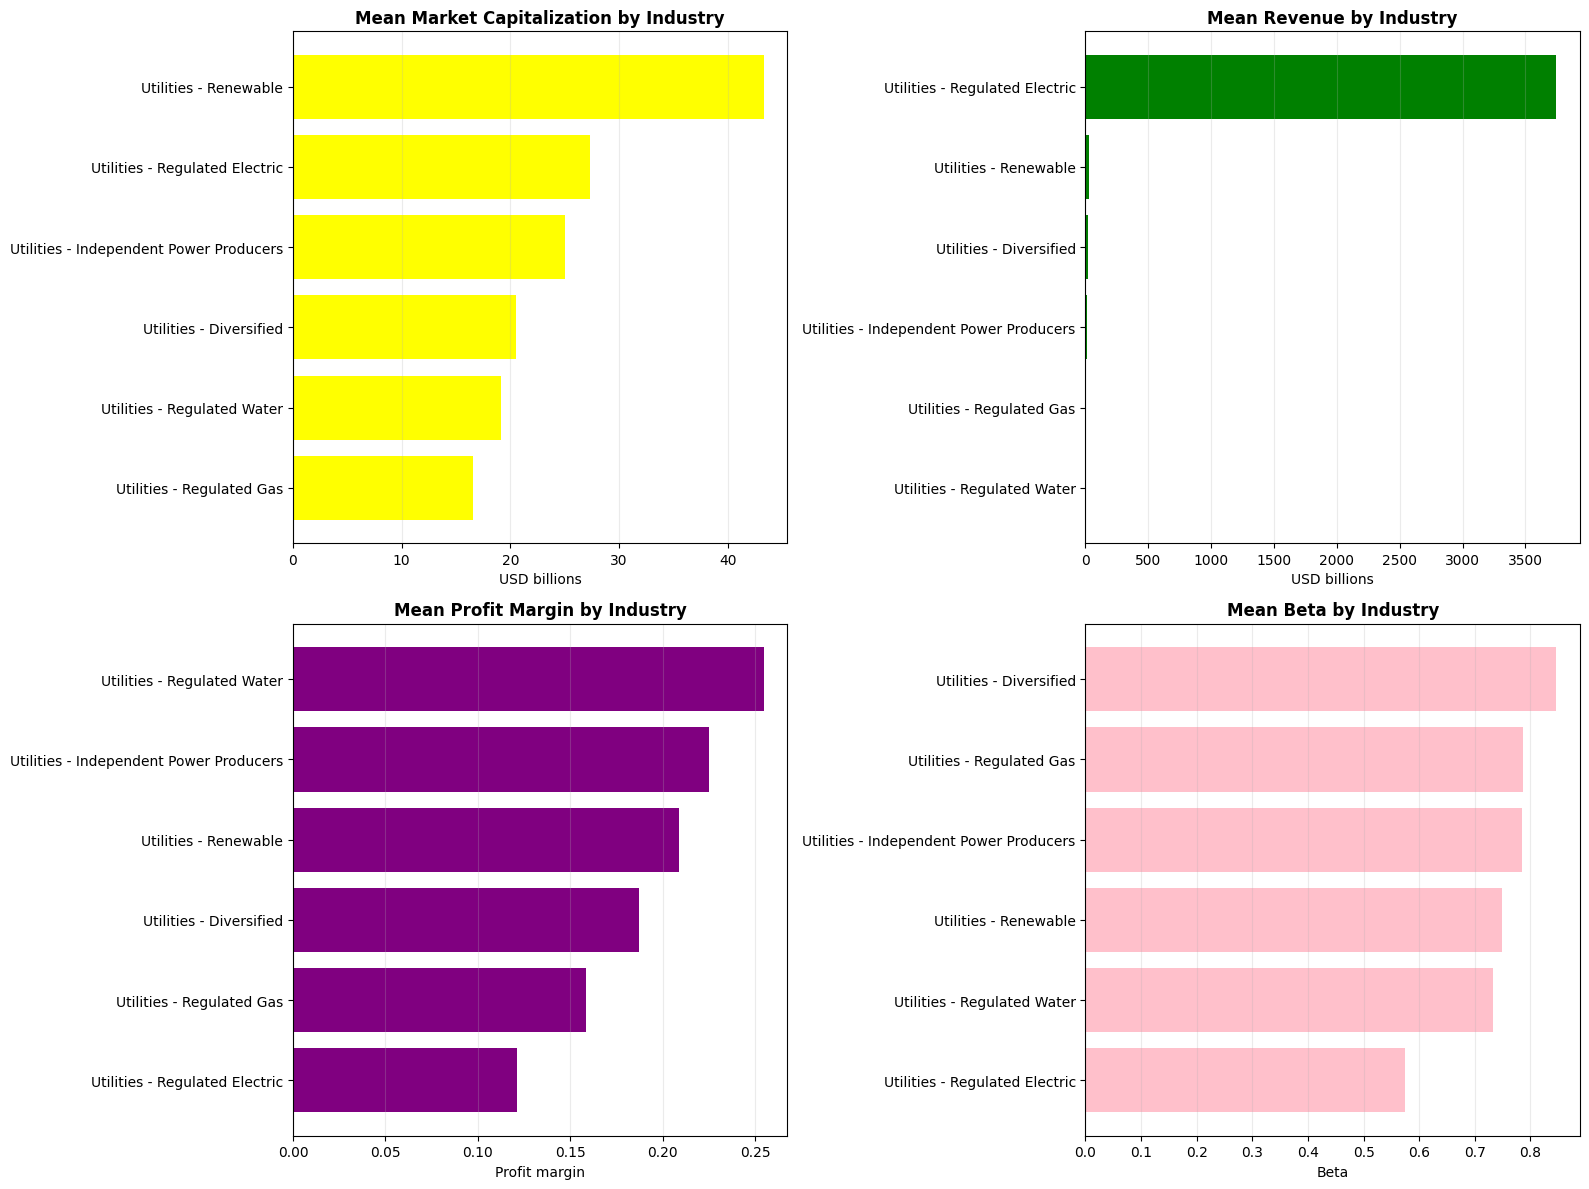

In [222]:
df_new["revenue_billion"] = df_new["total_revenue"] / 1000000000

industry_mcap = (
    df_new
    .groupby("industry")["market_cap_billion"]
    .mean()
    .dropna()
    .sort_values()
)

industry_revenue = (
    df_new
    .groupby("industry")["revenue_billion"]
    .mean()
    .dropna()
    .sort_values()
)

industry_profit = (
    df_new
    .groupby("industry")["profit_margins"]
    .mean()
    .dropna()
    .sort_values()
)

industry_beta = (
    df_new
    .groupby("industry")["beta"]
    .mean()
    .dropna()
    .sort_values()
)


fig3, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 12)
)

ax_mcap = axes[0, 0]
ax_revenue = axes[0, 1]
ax_profit = axes[1, 0]
ax_beta = axes[1, 1]

#graphs
ax_mcap.barh(
    industry_mcap.index,
    industry_mcap.values,
    color="yellow"
)

ax_mcap.set_title("Mean Market Capitalization by Industry")
ax_mcap.set_xlabel("USD billions")
ax_mcap.grid(axis="x", alpha=0.25)

ax_revenue.barh(
    industry_revenue.index,
    industry_revenue.values,
    color="green"
)

ax_revenue.set_title("Mean Revenue by Industry")
ax_revenue.set_xlabel("USD billions")
ax_revenue.grid(axis="x", alpha=0.25)

ax_profit.barh(
    industry_profit.index,
    industry_profit.values,
    color="purple"
)

ax_profit.set_title("Mean Profit Margin by Industry")
ax_profit.set_xlabel("Profit margin")
ax_profit.grid(axis="x", alpha=0.25)

ax_beta.barh(
    industry_beta.index,
    industry_beta.values,
    color="pink"
)

ax_beta.set_title("Mean Beta by Industry")
ax_beta.set_xlabel("Beta")
ax_beta.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

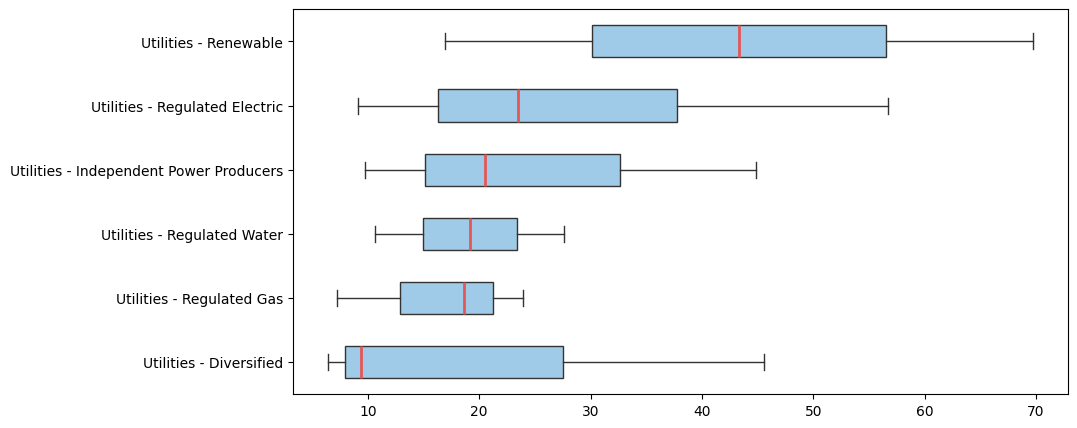

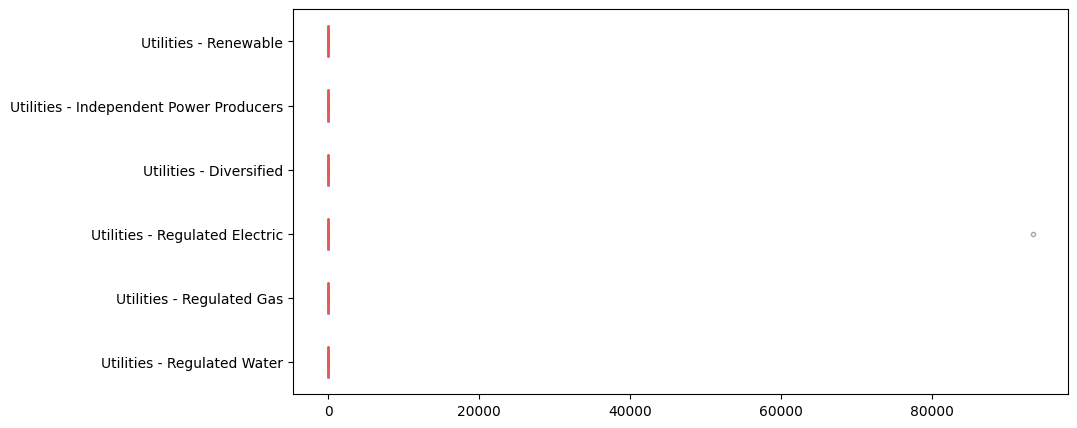

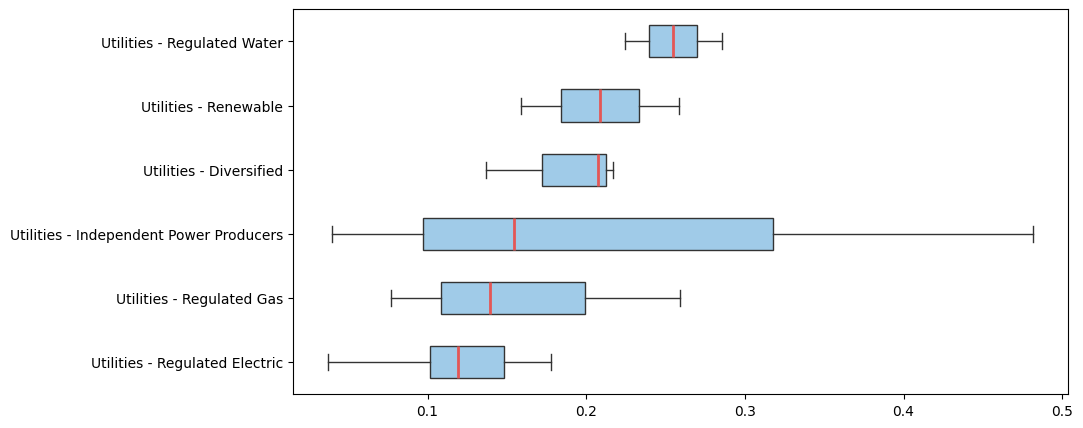

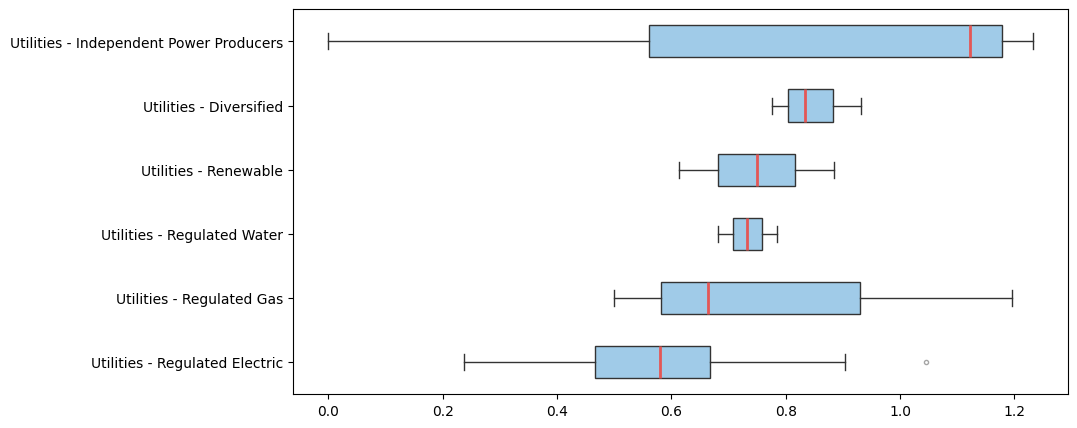

In [265]:
industry_order_mca = (
    df_new.groupby("industry")["market_cap_billion"]
    .median()
    .sort_values(ascending=True)
    .index
)

box_data_mcap = [
    df_new.loc[df_new["industry"] == industry, "market_cap_billion"].values
    for industry in industry_order_mca
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    box_data_mcap,
    tick_labels=industry_order_mca,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#A0CBE8", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
)

plt.show()

#total_revenue

df_new["total_revenue_billions"] = df_new["total_revenue"] / 1000000000

industry_order_tr = (
    df_new.groupby("industry")["total_revenue"]
    .median()
    .sort_values(ascending=True)
    .index
)

box_data_tr = [
    df_new.loc[df_new["industry"] == industry, "total_revenue_billions"].values
    for industry in industry_order_tr
]

fig, ax2 = plt.subplots(figsize=(10, 5))
ax2.boxplot(
    box_data_tr,
    tick_labels=industry_order_tr,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#A0CBE8", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
)

plt.show()

#profit margin

industry_order_pm = (
    df_new.groupby("industry")["profit_margins"]
    .median()
    .sort_values(ascending=True)
    .index
)

box_data_pm = [
    df_new.loc[df_new["industry"] == industry, "profit_margins"].values
    for industry in industry_order_pm
]

fig, ax3 = plt.subplots(figsize=(10, 5))
ax3.boxplot(
    box_data_pm,
    tick_labels=industry_order_pm,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#A0CBE8", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
)

plt.show()

#beta

industry_order_beta = (
    df_new.groupby("industry")["beta"]
    .median()
    .sort_values(ascending=True)
    .index
)

box_data_beta = [
    df_new.loc[df_new["industry"] == industry, "beta"].values
    for industry in industry_order_beta
]

fig, ax3 = plt.subplots(figsize=(10, 5))
ax3.boxplot(
    box_data_beta,
    tick_labels=industry_order_beta,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#A0CBE8", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
)

plt.show()

In [295]:
df_filter = df_new.copy()
df_filter = df_new[
    ((df_new["industry"] == "Utilities - Regulated Water") |
    (df_new["industry"] == "Utilities - Independent Power Producers") |
    (df_new["industry"] == "Utilities - Regulated Electric") |
    (df_new["industry"] == "Utilities - Regulated Gas")) &
    (df_new["total_revenue_billions"] < 1000)
    ]

display(df_filter)

,company_name,sector,symbol,market_cap,industry,total_revenue,profit_margins,beta,market_cap_billion,total_revenue_billions
209,American Electric Power Company,Utilities,AEP,56683405312,Utilities - Regulated Electric,19721299968,0.15045,0.492,56.683405,19.721300
249,"Dominion Energy, Inc.",Utilities,D,46845739008,Utilities - Regulated Electric,14458999808,0.14690,0.584,46.845739,14.459000
260,Exelon Corporation,Utilities,EXC,45015011328,Utilities - Regulated Electric,23028000768,0.10683,0.580,45.015011,23.028001
261,Vistra Corp.,Utilities,VST,44866764800,Utilities - Independent Power Producers,17223999488,0.15438,1.232,44.866765,17.223999
281,Public Service Enterprise Group,Utilities,PEG,41530163200,Utilities - Regulated Electric,10289999872,0.17221,0.617,41.530163,10.290000
291,Xcel Energy Inc.,Utilities,XEL,40270401536,Utilities - Regulated Electric,13441000448,0.14404,0.387,40.270402,13.441000
304,"Consolidated Edison, Inc.",Utilities,ED,38301233152,Utilities - Regulated Electric,15256000512,0.11930,0.285,38.301233,15.256001
307,Pacific Gas & Electric Co.,Utilities,PCG,37729501184,Utilities - Regulated Electric,24419000320,0.10136,1.045,37.729501,24.419000
313,Entergy Corporation,Utilities,ETR,36460539904,Utilities - Regulated Electric,11879653376,0.08886,0.668,36.460540,11.879653
323,"WEC Energy Group, Inc.",Utilities,WEC,34256850944,Utilities - Regulated Electric,8599900160,0.17758,0.443,34.256851,8.599900


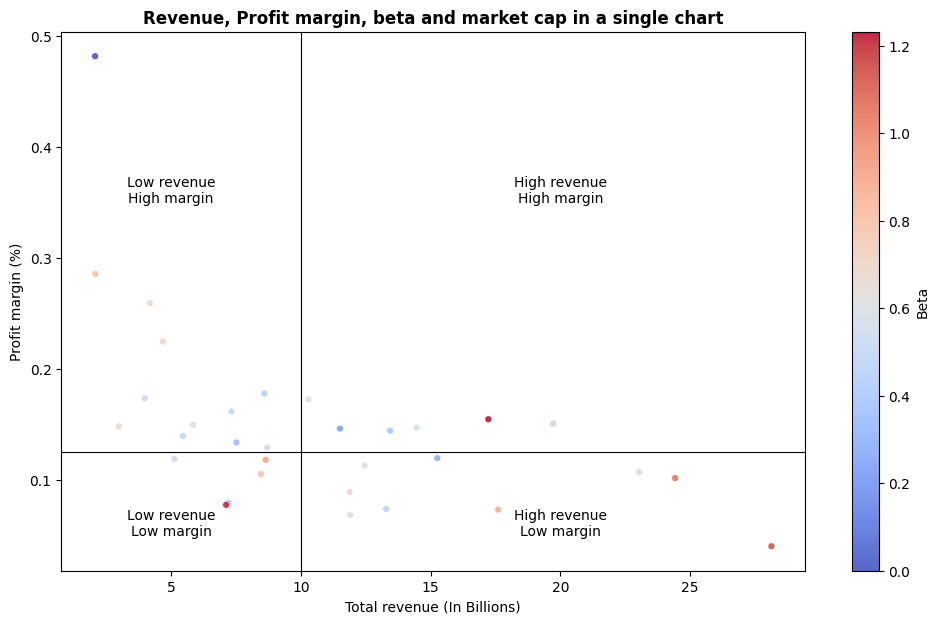

In [343]:
fig4, bubble = plt.subplots(figsize=(12, 7))

sizes = (df_filter["market_cap_billion"] / 8).clip(lower=25, upper=600)

points = bubble.scatter(
    df_filter["total_revenue_billions"],
    df_filter["profit_margins"],
    s=sizes,
    c=df_filter["beta"],
    cmap="coolwarm",
    alpha=0.85,
    edgecolors="white",
    linewidth=0.5
)

bubble.axhline(0.125, color="black", linewidth=0.8)
bubble.axvline(10, color="black", linewidth=0.8)

bubble.text(20,0.35, "High revenue\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
bubble.text(20, 0.05, "High revenue\nLow margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
bubble.text(5, 0.35, "Low revenue\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
bubble.text(5, 0.05, "Low revenue\nLow margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

bubble.set_title("Revenue, Profit margin, beta and market cap in a single chart")
bubble.set_xlabel("Beta")
bubble.set_xlabel("Total revenue (In Billions)")
bubble.set_ylabel("Profit margin (%)")

cbar = plt.colorbar(points, ax=bubble)
cbar.set_label("Beta")

plt.show()

[*********************100%***********************]  7 of 7 completed


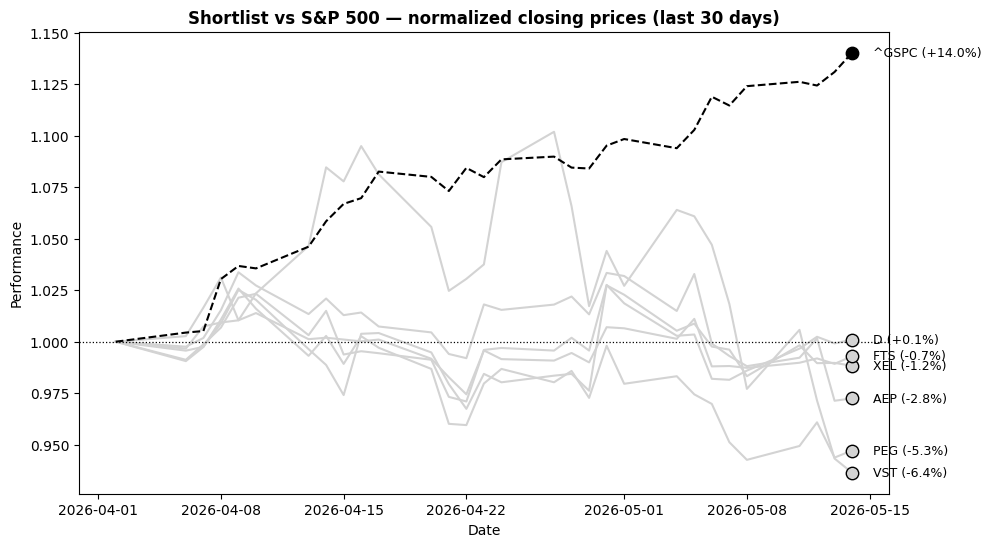

In [379]:
quadrant_high = df_filter[(df_filter["profit_margins"] > 0.125) & (df_filter["total_revenue_billions"] > 10)]

quadrant_low = df_filter[(df_filter["profit_margins"] < 0.125) & (df_filter["total_revenue_billions"] < 10)]

import yfinance as yf

tickers =quadrant_high["symbol"].tolist() + ["^GSPC"]
dt = yf.download(tickers, period="30d", interval="1d", auto_adjust=True)
closing_prices = dt["Close"]

normalized_prices = closing_prices / closing_prices.iloc[0]

fig, spgraph = plt.subplots(figsize=(12, 6))
sp500_final = normalized_prices["^GSPC"].iloc[-1]

for ticker in tickers:
    ticker_final = normalized_prices[ticker].iloc[-1]
    if ticker == "^GSPC":
        line_color, line_style = "black", "--"
    else:
        line_color = "steelblue" if ticker_final > sp500_final else "lightgrey"
        line_style = "-"
    spgraph.plot(normalized_prices.index, normalized_prices[ticker],
            color=line_color, linestyle=line_style, linewidth=1.5)
    final_date  = normalized_prices.index[-1]
    spgraph.scatter(final_date, ticker_final,
               color=line_color, edgecolor="black", zorder=5, s=80)

    pct_change    = (ticker_final - 1) * 100
    label_text    = f"{ticker} ({pct_change:+.1f}%)"

    spgraph.annotate(label_text,
                xy=(final_date, ticker_final),
                xytext=(15, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
                color="black")

fig.subplots_adjust(right=0.80)
spgraph.axhline(1, color="black", linewidth=0.9, linestyle=":")

spgraph.set_title("Shortlist vs S&P 500 — normalized closing prices (last 30 days)")
spgraph.set_xlabel("Date")
spgraph.set_ylabel("Performance")

plt.show()
